# Exploring the simulated data

This notebook walks through the **molecular data** iscc produces, one modality at a time:
bulk DNA, single-cell DNA, single-cell RNA (with scanpy), and Visium spatial transcriptomics
(with squidpy).

Because iscc knows the **true cell type** of every cell, we annotate the AnnData objects with it
and compare the unsupervised clusters/niches against the ground truth.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import squidpy as sq
from collections import Counter
from iscc.constants import normal_names
from iscc.tumor.models import GenotypeTumor
from iscc.sample.biopsy.biopsy import Biopsy
from iscc.data import bulkDNA, scDNA, scRNA, Visium

sc.settings.verbosity = 0
CONFIG = os.path.join(os.getcwd(), "example_config.yaml")

# Grow one cm-scale tissue (~8.5 mm, ~10^6 cells): its ground truth is the shared source for every
# assay below. cell_data is a memory-safe subsample (max_cells) of the whole tumour; growing to the
# DCIS->IDC state takes ~3 min.
tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=150, seed=2)
cd = tumor.cell_data
print(f"tumor: {tumor.get_cancer_size()} cancer / {tumor.get_tumor_size()} total cells "
      f"| cell_data subsample: {cd['cell_snv'].shape[0]} cells")

# Ground-truth cell type per cell: cancer, or one of the normal types.
true_type = cd["cell_type"]["cell_id"].astype(str)
def coarse_type(v):
    return v if v in normal_names else "cancer"

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


tumor: 323342 cancer / 588938 total cells | cell_data subsample: 49769 cells


## The ground truth

Before any assay, iscc knows everything: which genes are drivers, and every cell's true SNVs,
copy number, expression, and spatial location. The assays below are noisy, partial views of this.

600 genes | 10 oncogenes, 8 tumour suppressors


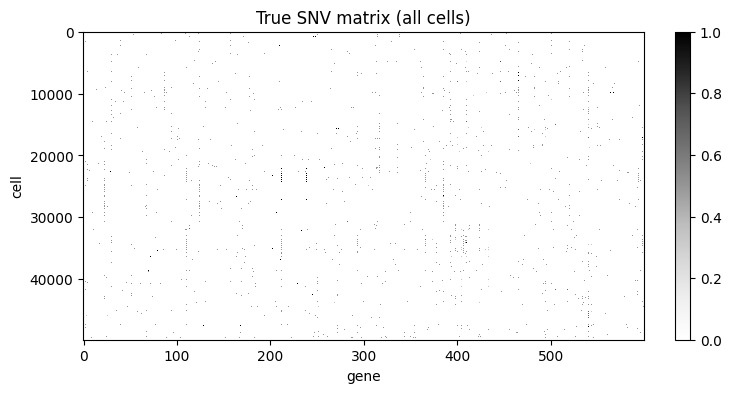

In [2]:
drivers = tumor.get_gene_data()["driver_types"].iloc[:, 0]   # +1 oncogene, -1 TSG, 0 passenger
n_onc = int((drivers == 1).sum()); n_tsg = int((drivers == -1).sum())
print(f"{len(drivers)} genes | {n_onc} oncogenes, {n_tsg} tumour suppressors")

true_snv = cd["cell_snv"]
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(true_snv.values, aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("gene"); ax.set_ylabel("cell"); ax.set_title("True SNV matrix (all cells)")
plt.colorbar(im, ax=ax, fraction=0.046)

## The biopsy sample

A `Biopsy` captures a spatially-realistic subset of cells while preserving their ground truth.
Here we take a **punch** (disk) over the `cell_crd` grid, then slice every ground-truth matrix
down to the chosen cells to get the `sample` the assays will sequence.

punch biopsy on the lesion: 4206 / 49769 cells (2955 cancer)


Text(0.5, 1.0, 'Biopsy on the invasive lesion')

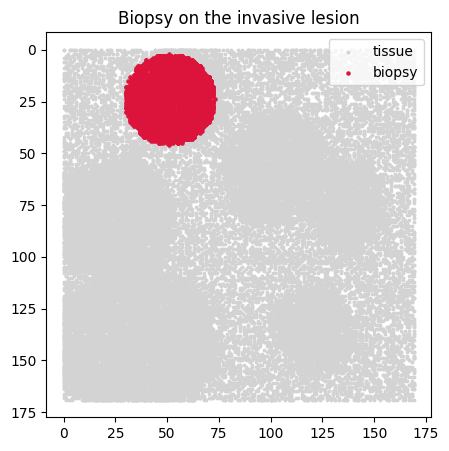

In [3]:
# Target the lesion: centre the punch on the DENSEST cancer focus so the assays sample tumour cells
# (a random punch of a mostly-stromal cm-scale tissue would be almost all stroma).
canc = cd["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").values
top_deme = Counter(cd["cell_deme"]["deme_id"][canc]).most_common(1)[0][0]
center = tuple(tumor.deme_coords[top_deme])
bx = Biopsy(cd, rng=np.random.default_rng(0))
chosen, region, geom = bx.sample(biopsy_type="punch", center=center, radius=22)   # ~1.1 mm core
sample = {k: df.loc[chosen] for k, df in cd.items()}
n_can = int(sample["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").sum())
print(f"punch biopsy on the lesion: {len(chosen)} / {len(cd['cell_snv'])} cells ({n_can} cancer)")

crd = cd["cell_crd"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(crd["col"], crd["row"], s=3, c="lightgrey", label="tissue")
ax.scatter(crd.loc[chosen, "col"], crd.loc[chosen, "row"], s=5, c="crimson", label="biopsy")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.legend(); ax.set_title("Biopsy on the invasive lesion")

## Bulk DNA-seq

Bulk DNA pools the sampled cells. We get a per-gene coverage and alt-read count, from which we
read out the **variant allele frequency (VAF)** spectrum.

top variant genes: ['G_7_43', 'G_4_15', 'G_0_30', 'G_10_37', 'G_8_9']


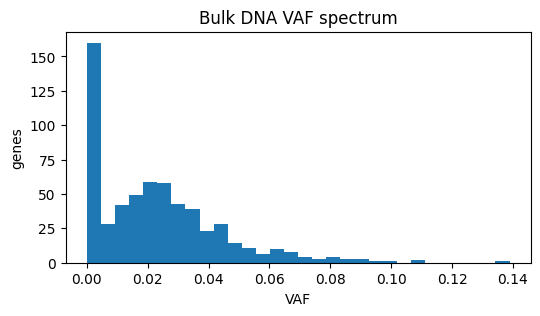

In [4]:
bd = bulkDNA(n_reads=50000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(sample)
vaf = bd.observed_data["vaf"][bd.observed_data["coverage"] > 0]   # drop zero-coverage loci
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30); ax.set_xlabel("VAF"); ax.set_ylabel("genes"); ax.set_title("Bulk DNA VAF spectrum")
print("top variant genes:", list(vaf.sort_values(ascending=False).head(5).index))

## Single-cell DNA-seq

scDNA resolves SNVs per cell. We compute a per-cell VAF matrix (alt / coverage) — the substrate
for clone reconstruction.

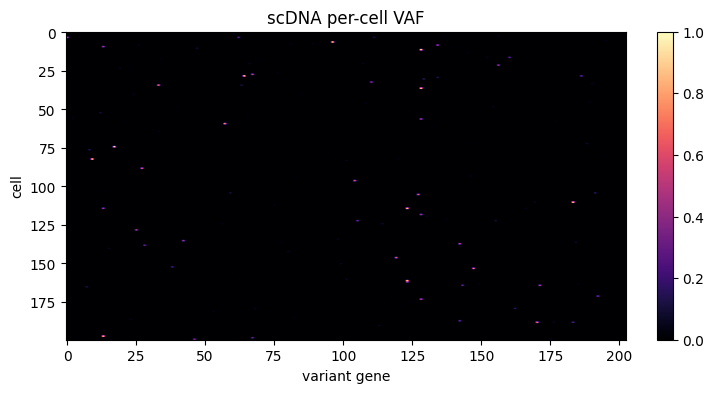

In [5]:
sd = scDNA(n_cells=200, breadth="wgs")
sd.run(sample)
sc_vaf = sd.vaf.fillna(0)
keep = sc_vaf.columns[sc_vaf.sum(0) > 0]   # genes with any signal
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(sc_vaf[keep].values, aspect="auto", cmap="magma")
ax.set_xlabel("variant gene"); ax.set_ylabel("cell"); ax.set_title("scDNA per-cell VAF")
plt.colorbar(im, ax=ax, fraction=0.046)

## Single-cell RNA-seq

scRNA gives UMI counts per cell. We turn the assay into an `AnnData` with `sr.to_anndata()`,
**annotate each cell with its true type** (`adata.obs['cell_type']`), then run a standard scanpy
workflow: QC, normalization, PCA, neighbours, Leiden clustering and UMAP. Colouring the UMAP by
the true cell type shows how well the unsupervised clusters recover it.

In [6]:
sr = scRNA(n_reads=4000, n_cells=400)
sr.run(sample)
adata = sr.to_anndata()
# ground-truth cell-type annotation
adata.obs["cell_type"] = pd.Categorical(true_type.reindex(adata.obs_names).map(coarse_type))
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata)
print("cell-type annotations:", dict(adata.obs["cell_type"].value_counts()))

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cell-type annotations: {'cancer': 289, 'stromal': 108, 'epithelial': 3}


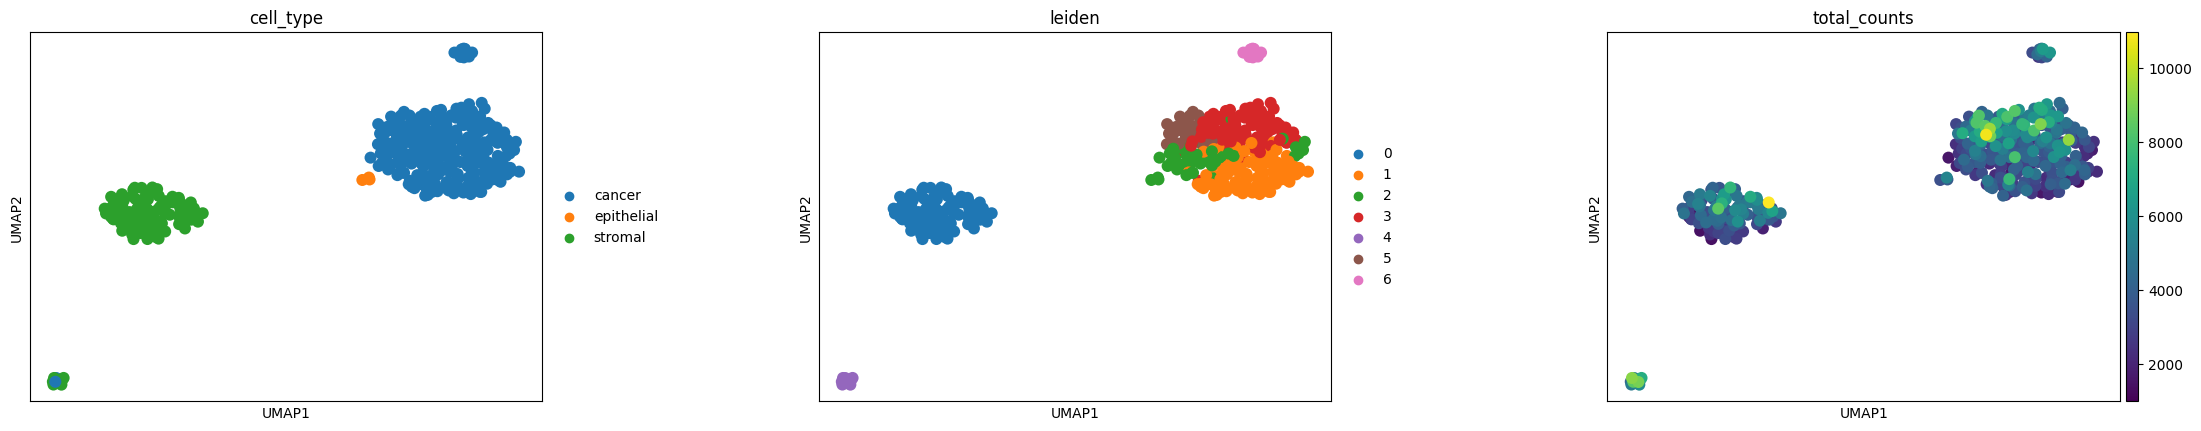

In [7]:
sc.pl.umap(adata, color=["cell_type", "leiden", "total_counts"], wspace=0.4)

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:446: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin, ymax)


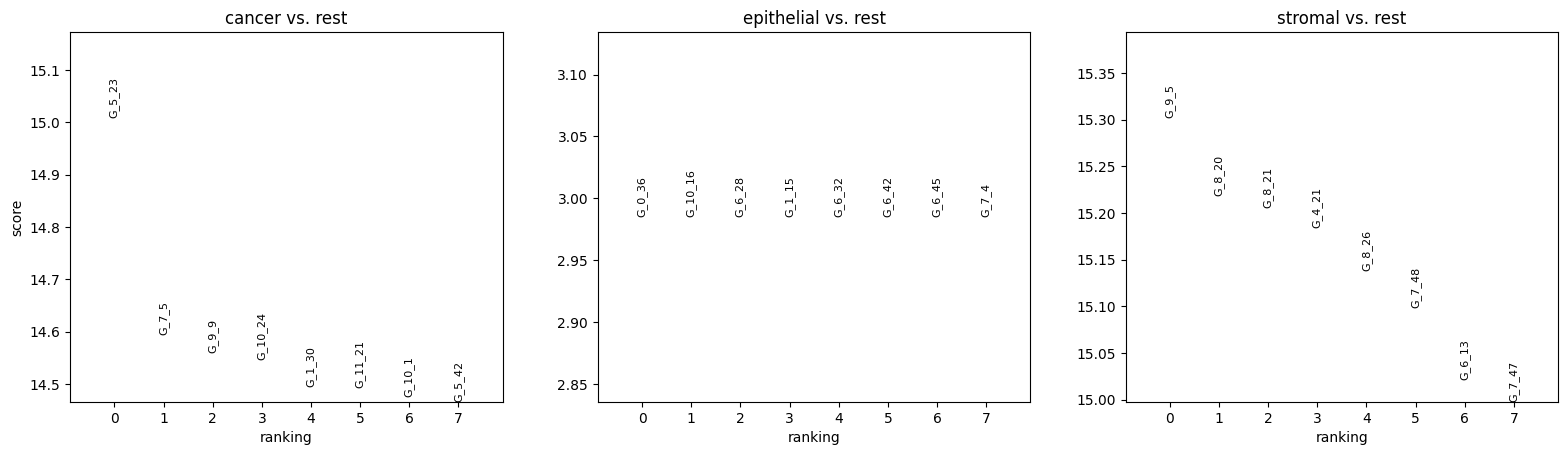

In [8]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=8, sharey=False)

## Visium spatial transcriptomics

A Visium slide is a **fixed** capture grid — the same hexagonal array of spots regardless of the
tissue placed on it (10x v1: **4,992 spots at 100 µm pitch** = 2 demes at this scale). Unlike the
biopsy above, an ST section spans a **large tissue area**, so we lay the slide over a thin section
of the **whole tumour**. Because the tumour (~8.5 mm) is **larger than the ~7.8 mm slide**, the slide
samples a **subset** of it.

The section is memory-safe: each deme is a 3-D column, so a 2-D section keeps only a thin slice — and
the `max_cells` subsample already thins each deme's column, so the subsample *is* a section (we
re-materialise a bit denser, still bounded, for a realistic cells/spot). `run(grid_side=None)` uses
the fixed v1 slide; `to_anndata()` returns a standard 10x AnnData (obsm `spatial`, `uns['spatial']`
with an H&E-like image, `in_tissue`). Every panel below is `sq.pl.spatial_scatter` on **spot-level**
quantities — never per cell.

In [9]:
# The Visium slide is a FIXED 10x v1 array (4,992 spots, 100 um pitch = 2 demes) laid over a thin
# SECTION of the WHOLE tumour (not the biopsy). The v1 slide spans ~156 x 128 demes, SMALLER than the
# 170-deme tumour, so it captures a SUBSET: masses outside the slide are never sampled. The max_cells
# subsample already thins each deme's 3-D column, so it IS a thin section; re-materialise a bit denser
# (still bounded, memory-safe) for a realistic cells/spot, then place+centre it on the slide.
from scipy.spatial import cKDTree

section = tumor.make_cell_data(max_cells=130000)      # a bounded thin section of the whole tumour
vz = Visium(n_reads=20000, spot_pitch=2.0, spot_radius=0.55, section_frac=1.0, seed=0)
vz.run(section, grid_side=None)                       # grid_side=None -> the fixed v1 slide
vis = vz.to_anndata()          # standard 10x AnnData: obsm['spatial'], uns['spatial'], in_tissue
vis.obs["total_counts"] = np.asarray(vis.X.sum(1)).ravel()
lib = list(vis.uns["spatial"])[0]
it = vis.obs["in_tissue"].values == 1
sp2 = vis.obsm["spatial"]                             # (x, y) = (col, row) in the slide frame
print(f"Visium v1 slide: {vis.n_obs} spots | in-tissue: {int(it.sum())} "
      f"| median cells / in-tissue spot: {int(np.median(vis.obs.loc[it, 'n_cells']))}")

# DENSE H&E from the per-deme cell COUNTS (complete + high-contrast, unlike rasterising the thin
# subsample). It lives in the deme-grid frame; _place_section only TRANSLATES the section onto the
# slide, so shift the spots back by that translation to overlay them on the H&E.
he, PX = tumor.he_image(px=6)
spot_rc = vz._layout(None)                            # (row, col) spot centres, slide frame
sec_rc = section["cell_crd"][["row", "col"]].to_numpy(float)
shift = spot_rc.mean(0) - sec_rc.mean(0)             # the centring translation _place_section applied
spot_row = (sp2[:, 1] - shift[0]) * PX               # spot centres in the H&E (deme) frame
spot_col = (sp2[:, 0] - shift[1]) * PX

# ground-truth cancer fraction per spot (iscc knows every cell's type) — the spatial structure
placed = vz._place_section(section, spot_rc)
pc = placed["cell_crd"][["row", "col"]].to_numpy(float)
wcan = section["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").values.astype(float)
d, idx = cKDTree(spot_rc[:, ::-1]).query(pc)          # spot centres as (row, col)
insp = d <= vz.hypers.spot_radius
scan = np.zeros(vis.n_obs); stot = np.zeros(vis.n_obs)
np.add.at(scan, idx[insp], wcan[insp]); np.add.at(stot, idx[insp], 1.0)
vis.obs["cancer_fraction"] = np.divide(scan, stot, out=np.zeros(vis.n_obs), where=stot > 0)

# spot-level analysis (standard scanpy) on the in-tissue spots -> unsupervised spatial niches
tissue = vis[it].copy()
sc.pp.normalize_total(tissue); sc.pp.log1p(tissue)
sc.pp.pca(tissue, n_comps=20); sc.pp.neighbors(tissue)
sc.tl.leiden(tissue, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)
vis.obs["niche"] = pd.Categorical(tissue.obs["leiden"].reindex(vis.obs_names))    # off-tissue -> NaN
print(f"spot niches (leiden): {tissue.obs['leiden'].nunique()} | "
      f"cancer-rich spots (>50%): {int((vis.obs['cancer_fraction'] > 0.5).sum())}")

Visium v1 slide: 4992 spots | in-tissue: 4601 | median cells / in-tissue spot: 5


spot niches (leiden): 4 | cancer-rich spots (>50%): 2038


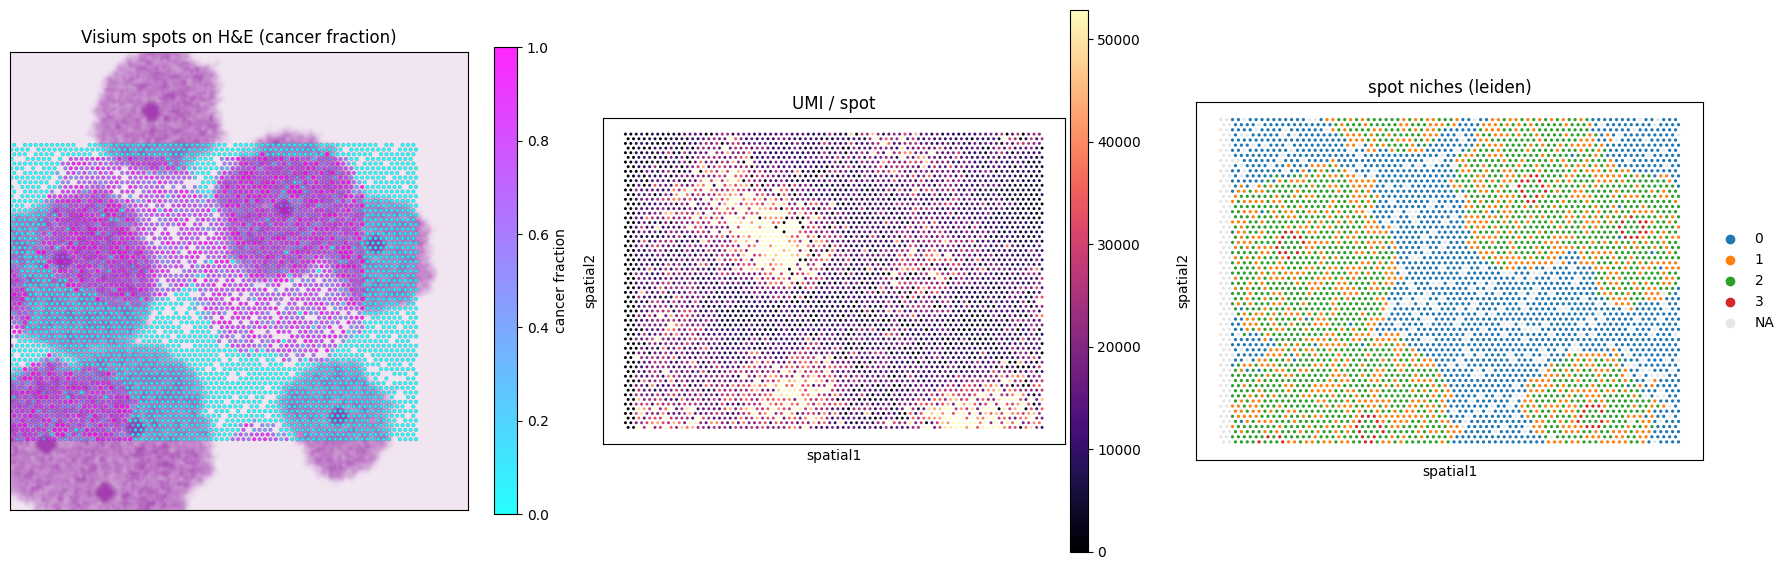

In [10]:
frac = vis.obs["cancer_fraction"].values
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
# left: the fixed v1 spot array overlaid ON the dense H&E, coloured by ground-truth cancer fraction.
# The H&E masses that stick out beyond the spot rectangle are the part of the tumour the slide misses.
axes[0].imshow(he, origin="upper")
good = it & np.isfinite(frac)
s0 = axes[0].scatter(spot_col[good], spot_row[good], c=frac[good], s=7, cmap="cool", vmin=0, vmax=1,
                     edgecolors="k", linewidths=0.1, alpha=0.85)
axes[0].set_xlim(0, he.shape[1]); axes[0].set_ylim(he.shape[0], 0)
axes[0].set_title("Visium spots on H&E (cancer fraction)"); axes[0].set_xticks([]); axes[0].set_yticks([])
plt.colorbar(s0, ax=axes[0], fraction=0.046, label="cancer fraction")
# middle: sequencing depth per spot (squidpy) — clip vmax so one hot spot doesn't blacken the rest
umi_vmax = float(np.percentile(vis.obs["total_counts"].values[it], 95))
sq.pl.spatial_scatter(vis, color="total_counts", library_id=lib, ax=axes[1], fig=fig, img=False,
                      shape="circle", size=1.0, cmap="magma", vmax=umi_vmax, title="UMI / spot")
# right: unsupervised spatial niches recover the tumour regions (squidpy)
sq.pl.spatial_scatter(vis, color="niche", library_id=lib, ax=axes[2], fig=fig, img=False,
                      shape="circle", size=1.0, na_color="0.9", title="spot niches (leiden)")
plt.tight_layout()

## Recap

We took one simulated tumor and viewed it through bulk DNA, scDNA, scRNA and Visium — each a
noisy, partial measurement of the same ground truth. Because the ground truth (each cell's true
type, clone, copy number and mutations) is known, these datasets are ideal benchmarks for
tumor-evolution methods.

The assays model realistic technical structure — negative-binomial + dropout scRNA,
allele-specific single-cell DNA with allelic dropout, a read/FASTQ mode, and spatial spot mixing
with autocorrelation — and their parameters can be fit to real reference data. Further
analysis-demo notebooks (MHN from DNA, niche identification, batch effects, combining modalities,
real-data comparison) build on these datasets.